# Week 2 - Preprocessing & Baseline Model
**Project:** Sentiment Analysis of myBCA Mobile Banking App Reviews
**Author:** Elvia Aptanisa
**Week:** 2
**Purpose:** Clean and prepare the dataset for model training, then build a baseline model using Logistic Regression + TF-IDF.

---

## Step 1 - Install & Import Library

In [4]:
!pip install PySastrawi

import pandas as pd
import numpy as np
import re
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2 - Load Dataset

In [5]:
df = pd.read_csv('mybca_reviews.csv')
print(f"Dataset loaded: {len(df)} reviews")
print(df.head())

Dataset loaded: 5000 reviews
                                              review  rating sentiment
0                                              bagus       5  Positive
1                                                 ok       5  Positive
2  ko skrg gak ad notifikasi uang masuk y dari ak...       5  Positive
3                                               asik       5  Positive
4  BCA ID ku keblokir terus ke apa sih! dari Janu...       1  Negative


## Step 3 - Remove Duplicates

In [6]:
before = len(df)
df = df.drop_duplicates(subset='review', keep='first')
after = len(df)

print(f"Before : {before} reviews")
print(f"Removed: {before - after} duplicates")
print(f"After  : {after} reviews")

Before : 5000 reviews
Removed: 718 duplicates
After  : 4282 reviews


## Step 4 - Text Cleaning

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['review_clean'] = df['review'].apply(clean_text)

print("Text cleaning done!")
print("\nContoh hasil cleaning:")
print(f"Before: {df['review'].iloc[4]}")
print(f"After : {df['review_clean'].iloc[4]}")

Text cleaning done!

Contoh hasil cleaning:
Before: BCA ID ku keblokir terus ke apa sih! dari Januari sudah 5x keblokir perkara logout out, masukin password juga copy paste sama persis tapi selalu salah, sekali salah BCA id langsung diblokir sistem,kalau begini terus buat apa ada my BCA?. sebenernya ini masalahnya di sistem apa emang aku dilarang pakai BCA lagi yaa?. emang aku pake ponsel baru tapi sistemnya jangan terlalu sensitif dong login juga dari tempat yang sama jaringan yang sama ,pulsa abis hanya untuk hubungin CS
After : bca id ku keblokir terus ke apa sih dari januari sudah x keblokir perkara logout out masukin password juga copy paste sama persis tapi selalu salah sekali salah bca id langsung diblokir sistemkalau begini terus buat apa ada my bca sebenernya ini masalahnya di sistem apa emang aku dilarang pakai bca lagi yaa emang aku pake ponsel baru tapi sistemnya jangan terlalu sensitif dong login juga dari tempat yang sama jaringan yang sama pulsa abis hanya untuk hubungin

## Step 5 - Normalization (Fix Abbreviations)

In [8]:
slang_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'tdk': 'tidak', 'ngga': 'tidak',
    'gk': 'tidak', 'g': 'tidak', 'nggak': 'tidak',
    'udh': 'sudah', 'udah': 'sudah', 'sdh': 'sudah',
    'blm': 'belum', 'belom': 'belum',
    'lg': 'lagi', 'lg': 'lagi',
    'bgt': 'banget', 'bngt': 'banget',
    'yg': 'yang', 'yng': 'yang',
    'dgn': 'dengan', 'dg': 'dengan',
    'utk': 'untuk', 'tuk': 'untuk',
    'krn': 'karena', 'karna': 'karena',
    'gmn': 'gimana', 'gimn': 'gimana',
    'knp': 'kenapa',
    'hrs': 'harus',
    'msh': 'masih',
    'sdg': 'sedang', 'lg': 'sedang',
    'tp': 'tapi', 'tpi': 'tapi',
    'jg': 'juga', 'juga': 'juga',
    'sy': 'saya', 'aq': 'saya', 'ak': 'saya',
    'apk': 'aplikasi', 'app': 'aplikasi',
    'bkn': 'bukan',
    'emg': 'memang', 'emang': 'memang',
    'klo': 'kalau', 'kalo': 'kalau',
    'br': 'baru',
    'skrg': 'sekarang',
    'dtg': 'datang',
    'dpt': 'dapat',
    'bs': 'bisa', 'bsa': 'bisa',
    'dr': 'dari',
    'ke': 'ke',
    'sm': 'sama',
    'ok': 'oke', 'oke': 'oke',
    'nih': 'ini', 'ni': 'ini',
    'tuh': 'itu',
    'kyk': 'seperti', 'kyak': 'seperti',
    'lbh': 'lebih',
    'pgn': 'ingin', 'pengen': 'ingin',
    'nyoba': 'mencoba',
    'makasih': 'terima kasih', 'mksh': 'terima kasih', 'thx': 'terima kasih',
}

def normalize_text(text):
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]
    return ' '.join(words)

df['review_clean'] = df['review_clean'].apply(normalize_text)

print("Normalization done!")
print("\nContoh hasil normalisasi:")
print(f"Before: {df['review'].iloc[10]}")
print(f"After : {df['review_clean'].iloc[10]}")

Normalization done!

Contoh hasil normalisasi:
Before: Bank BCA sangat bermanfaat bagi kebutuhan Masyarakat 👍👍👍
After : bank bca sangat bermanfaat bagi kebutuhan masyarakat


## Step 6 - Stopword Removal & Stemming

In [9]:
factory_sw = StopWordRemoverFactory()
stopword_remover = factory_sw.create_stop_word_remover()

factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

def remove_stopwords_and_stem(text):
    text = stopword_remover.remove(text)
    text = stemmer.stem(text)
    return text

print("Processing... (ini butuh beberapa menit karena 4000+ reviews)")
df['review_clean'] = df['review_clean'].apply(remove_stopwords_and_stem)
print("Stopword removal & stemming done!")
print("\nContoh hasil:")
print(f"Before: {df['review'].iloc[0]}")
print(f"After : {df['review_clean'].iloc[0]}")

Processing... (ini butuh beberapa menit karena 4000+ reviews)
Stopword removal & stemming done!

Contoh hasil:
Before: bagus
After : bagus


## Step 7 - Train/Validation/Test Split

In [10]:
from sklearn.model_selection import train_test_split

X = df['review_clean']
y = df['sentiment']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)


print("Data split done!")
print(f"Training set  : {len(X_train)} reviews (70%)")
print(f"Validation set: {len(X_val)} reviews (15%)")
print(f"Test set      : {len(X_test)} reviews (15%)")
print(f"\nLabel distribution in training set:")
print(y_train.value_counts())

Data split done!
Training set  : 2998 reviews (70%)
Validation set: 641 reviews (15%)
Test set      : 643 reviews (15%)

Label distribution in training set:
sentiment
Negative    1704
Positive     990
Neutral      304
Name: count, dtype: int64


## Step 8 - Baseline Model (Logistic Regression + TF-IDF)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

print("Baseline model trained!")

Baseline model trained!


=== BASELINE MODEL RESULTS ===
              precision    recall  f1-score   support

    Negative       0.75      0.93      0.83       366
     Neutral       0.00      0.00      0.00        65
    Positive       0.79      0.69      0.74       212

    accuracy                           0.76       643
   macro avg       0.51      0.54      0.52       643
weighted avg       0.69      0.76      0.72       643



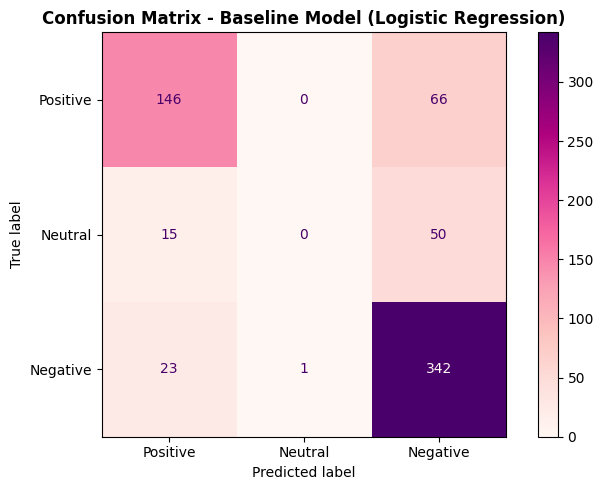


Baseline evaluation done!


In [16]:
y_pred = lr_model.predict(X_test_tfidf)

print("=== BASELINE MODEL RESULTS ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['Positive', 'Neutral', 'Negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Neutral', 'Negative'])

plt.figure(figsize=(7, 5))
disp.plot(cmap='RdPu', ax=plt.gca())
plt.title('Confusion Matrix - Baseline Model (Logistic Regression)', fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

print("\nBaseline evaluation done!")

## Step 9 - Remove Empty Reviews & Save Cleaned Dataset

In [18]:
before = len(df)
df_clean = df[['review_clean', 'sentiment']].copy()
df_clean.columns = ['review', 'sentiment']
df_clean = df_clean.dropna(subset=['review'])
df_clean = df_clean[df_clean['review'].str.strip() != '']
after = len(df_clean)

print(f"Removed empty reviews: {before - after}")
print(f"Final dataset        : {after} reviews")
print(f"\nLabel distribution:")
print(df_clean['sentiment'].value_counts())

df_clean.to_csv('mybca_reviews_clean.csv', index=False, encoding='utf-8-sig')
print("\n Cleaned dataset saved as 'mybca_reviews_clean.csv'")
print(df_clean.head())

Removed empty reviews: 34
Final dataset        : 4248 reviews

Label distribution:
sentiment
Negative    2431
Positive    1385
Neutral      432
Name: count, dtype: int64

 Cleaned dataset saved as 'mybca_reviews_clean.csv'
                                              review sentiment
0                                              bagus  Positive
1                                                oke  Positive
2  ko ad notifikasi uang aktivitas bagus ad notif...  Positive
3                                               asik  Positive
4  bca id ku blokir sih januari blokir perkara lo...  Negative
